In [65]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import TypedDict, List, Annotated, Optional
import numpy as np
import operator
from dotenv import load_dotenv
load_dotenv()

True

In [66]:
class UPSCState(BaseModel):
    essay: str
    language_feedback: Optional[str]= None
    language_improvement_area: Optional[str]= None
    analysis_feedback: Optional[str]= None
    analysis_improvement_area: Optional[str]= None 
    clarity_feedback: Optional[str]= None
    clarity_improvement_area: Optional[str]= None 
    overall_feedback: Optional[str]= None 
    overall_improvement_area: Optional[str]= None
    individual_score: Optional[Annotated[List[int], operator.add]]= None
    final_score: Optional[float]= None

In [67]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    language_improvement_area: str
    analysis_feedback: str
    analysis_improvement_area: str 
    clarity_feedback: str
    clarity_improvement_area: str 
    overall_feedback: str 
    overall_improvement_area: str
    individual_score: Annotated[List[int], operator.add]
    final_score: float

In [68]:
class EvaluationSchema(BaseModel):
    feedback: str= Field(description= 'Provide a detailed feedback of the essay')
    improvement_area: str= Field(description= 'Provide the area of improvement, what lacked and why were the marks deducted if any')
    score: int= Field(description= 'Provide a score out of 10', gt= 0, le=10)

In [69]:
model= ChatGoogleGenerativeAI(model= "gemini-2.0-flash")
structured_model= model.with_structured_output(EvaluationSchema)

In [70]:
def evaluate_language(state: UPSCState):
    prompt= f"You are UPSC exam evaluator focussing on language quality, provide a detailed feedback for this essay: {state['essay']}\n and give it a score out of 10, along with mentioning the area of improvement"
    result= structured_model.invoke(prompt)
    
    return {'language_feedback': result.feedback,
            'language_improvement_area': result.improvement_area,
            'individual_score': [result.score]}

In [71]:
def evaluate_analysis(state: UPSCState):
    prompt= f"You are UPSC exam evaluator focussing on analysis quality, provide a detailed feedback for this essay: {state['essay']}\n and give it a score out of 10, along with mentioning the area of improvement"
    result= structured_model.invoke(prompt)
    
    return {'analysis_feedback': result.feedback,
            'analysis_improvement_area': result.improvement_area,
            'individual_score': [result.score]}

In [72]:
def evaluate_thought(state: UPSCState):
    prompt= f"You are UPSC exam evaluator focussing on clarity about the topic quality, provide a detailed feedback for this essay: {state['essay']}\n and give it a score out of 10, along with mentioning the area of improvement"
    result= structured_model.invoke(prompt)
    
    return {'clarity_feedback': result.feedback,
            'clarity_improvement_area': result.improvement_area,
            'individual_score': [result.score]}

In [73]:
def overall_evaluation(state: UPSCState):
    prompt= f"You are UPSC exam evaluator focussing on overall quality, provide a detailed feedback for this essay: {state['essay']}\n and give it a score out of 10, along with mentioning the area of improvement"
    result= structured_model.invoke(prompt)
    
    return {'overall_feedback': result.feedback,
            'overall_improvement_area': result.improvement_area
    }

In [74]:
def score_aggregator(state: UPSCState):
    avg_score= np.mean(state['individual_score'])
    
    return {'final_score': avg_score}

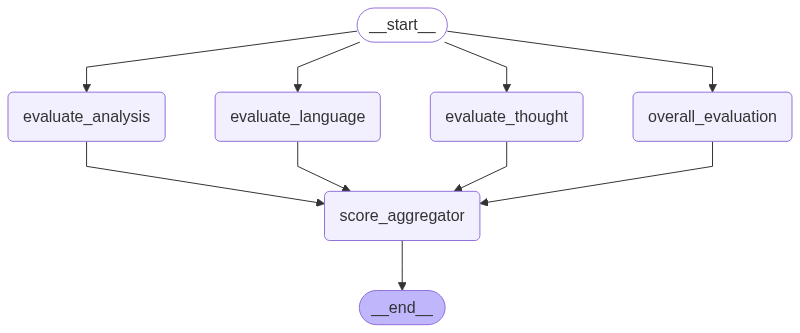

In [77]:
graph= StateGraph(UPSCState)
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('overall_evaluation', overall_evaluation)
graph.add_node('score_aggregator', score_aggregator)

# add edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')
graph.add_edge(START, 'overall_evaluation')
graph.add_edge('evaluate_language', 'score_aggregator')
graph.add_edge('evaluate_analysis', 'score_aggregator')
graph.add_edge('evaluate_thought', 'score_aggregator')
graph.add_edge('overall_evaluation', 'score_aggregator')
graph.add_edge('score_aggregator', END)

workflow= graph.compile()
workflow

In [76]:
essay= 'The Himalayas, being one of the youngest and most tectonically active mountain ranges, are highly prone to landslides. Steep slopes, fragile geological formations, intense monsoon rains, and frequent earthquakes contribute to their vulnerability. Human activities like deforestation, unplanned construction, and road cutting further destabilize the terrain. Climate change has intensified rainfall patterns and glacier melt, increasing landslide frequency. Landslides disrupt transport, destroy infrastructure, and pose serious threats to life in Himalayan regions. Effective mitigation requires geotechnical monitoring, afforestation, regulated development, and early warning systems. A balanced approach combining environmental sensitivity and sustainable planning is essential for long-term resilience.'

initial_state= {'essay': essay}

final_state= workflow.invoke(initial_state)
final_state

{'essay': 'The Himalayas, being one of the youngest and most tectonically active mountain ranges, are highly prone to landslides. Steep slopes, fragile geological formations, intense monsoon rains, and frequent earthquakes contribute to their vulnerability. Human activities like deforestation, unplanned construction, and road cutting further destabilize the terrain. Climate change has intensified rainfall patterns and glacier melt, increasing landslide frequency. Landslides disrupt transport, destroy infrastructure, and pose serious threats to life in Himalayan regions. Effective mitigation requires geotechnical monitoring, afforestation, regulated development, and early warning systems. A balanced approach combining environmental sensitivity and sustainable planning is essential for long-term resilience.',
 'language_feedback': "The essay provides a concise overview of the causes and effects of landslides in the Himalayas, along with potential mitigation strategies. It touches upon ke